In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Huggingface imports for LLaMA
from transformers import LlamaForCausalLM, LlamaTokenizer
import torch


In [ ]:
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

In [ ]:
# Load example data
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
df

In [ ]:
df.columns

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns

from dowhy import CausalModel

# Huggingface imports for LLaMA
from transformers import LlamaForCausalLM, LlamaTokenizer
import torch

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from dowhy import CausalModel
from transformers import LlamaTokenizer, LlamaForCausalLM

# Load and preprocess dataset
df = pd.read_csv("diabetes.csv")

# Strip whitespace from column names
df.columns = df.columns.str.strip()

# Replace invalid 0s with NaN for specific columns, then drop rows with NaNs
cols_with_invalid_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
missing_cols = [col for col in cols_with_invalid_zeros if col not in df.columns]
if missing_cols:
    raise KeyError(f"The following expected columns are missing in the dataset: {missing_cols}")
df[cols_with_invalid_zeros] = df[cols_with_invalid_zeros].replace(0, np.nan)
df.dropna(inplace=True)

# Binarize treatment based on median glucose (to get binary treatment)
treatment = "Glucose_bin"
df[treatment] = (df["Glucose"] > df["Glucose"].median()).astype(int)
outcome = "Outcome"
confounders = ['Age', 'BMI', 'Pregnancies']

# Normalize confounders (optional)
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[confounders] = scaler.fit_transform(df[confounders])

# Build DoWhy causal model
model = CausalModel(
    data=df_scaled,
    treatment=treatment,
    outcome=outcome,
    common_causes=confounders
)

# Identify causal effect
identified_estimand = model.identify_effect()

# Estimate causal effect using propensity score weighting
estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_weighting",
    target_units="ate"
)

print("Causal Estimate (ATE): ", estimate.value)

# Manually compute propensity scores using logistic regression
ps_model = LogisticRegression(max_iter=1000)
ps_model.fit(df_scaled[confounders], df_scaled[treatment])
pscore = ps_model.predict_proba(df_scaled[confounders])[:, 1]  # P(Treatment=1)

df_scaled['propensity_score'] = pscore

# Plot propensity score distribution by treatment group
plt.figure(figsize=(8, 5))
sns.kdeplot(df_scaled.loc[df_scaled[treatment] == 1, 'propensity_score'], label='Treated')
sns.kdeplot(df_scaled.loc[df_scaled[treatment] == 0, 'propensity_score'], label='Control')
plt.title("Propensity Score Distribution by Treatment Group")
plt.xlabel("Propensity Score")
plt.ylabel("Density")
plt.legend()
plt.show()

# Plot propensity score overlap (common support)
plt.figure(figsize=(8, 5))
sns.histplot(data=df_scaled, x='propensity_score', hue=treatment, element="step", stat="density", common_norm=False)
plt.title("Propensity Score Overlap by Treatment Group")
plt.show()

# Sensitivity analyses / robustness checks (refutation tests)
print("\nRunning refutation tests...\n")
refute_placebo = model.refute_estimate(identified_estimand, estimate, method_name="placebo_treatment_refuter")
print("Placebo Treatment Refuter Result: ", refute_placebo)

refute_random_common_cause = model.refute_estimate(identified_estimand, estimate, method_name="random_common_cause")
print("Random Common Cause Refuter Result: ", refute_random_common_cause)

refute_subset = model.refute_estimate(identified_estimand, estimate, method_name="data_subset_refuter")
print("Data Subset Refuter Result: ", refute_subset)

# Prepare summary text for LLaMA prompt
def summarize_feature(series):
    return f"mean={series.mean():.2f}, std={series.std():.2f}, min={series.min():.2f}, max={series.max():.2f}"

summary_text = f"""
Dataset summary for causal inference:

Treatment variable: {treatment} (binary indicator if glucose > median)
  {summarize_feature(df_scaled[treatment])}

Outcome variable: {outcome} (binary diabetes diagnosis)
  Outcome distribution: {df_scaled[outcome].value_counts().to_dict()}

Confounders:
"""
for c in confounders:
    summary_text += f"  {c}: {summarize_feature(df_scaled[c])}\n"

summary_text += f"""

Estimated Average Treatment Effect (ATE) of {treatment} on {outcome}: {estimate.value:.4f}

Diagnostics:
- Propensity score distribution plotted.
- Common support assumption checked.
- Refutation tests performed:
  * Placebo treatment refuter: {refute_placebo.new_effect}
  * Random common cause refuter: {refute_random_common_cause.new_effect}
  * Data subset refuter: {refute_subset.new_effect}

Please provide a detailed interpretation of this causal effect estimate,
discuss assumptions, potential sources of bias, robustness, and how
propensity score model diagnostics and sensitivity analyses inform confidence
in this estimate.
"""

print("=== Dataset and causal inference summary sent to LLaMA ===")
print(summary_text)

# Load LLaMA model and tokenizer (adjust path/model name as needed)
model_name = "meta-llama/Llama-2-7b-hf"
tokenizer = LlamaTokenizer.from_pretrained(model_name)
llama_model = LlamaForCausalLM.from_pretrained(model_name).to('cuda' if torch.cuda.is_available() else 'cpu')

def llama_causal_inference(prompt, max_new_tokens=350):
    inputs = tokenizer(prompt, return_tensors="pt").to(llama_model.device)
    outputs = llama_model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        eos_token_id=tokenizer.eos_token_id,
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# Generate detailed interpretation from LLaMA
llama_prompt = summary_text
causal_effect_interpretation = llama_causal_inference(llama_prompt)

print("\n=== LLaMA Causal Effect Interpretation ===\n")
print(causal_effect_interpretation)


/rodata/kern/m254629/miniconda3/envs/llama2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Causal Estimate (ATE):  0.2796170659306685


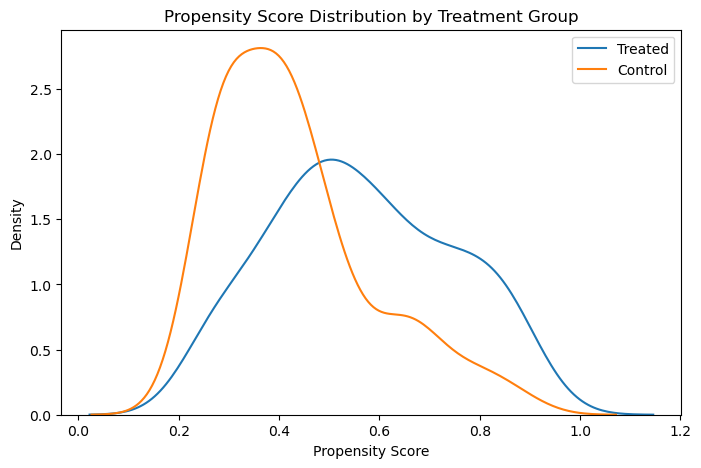

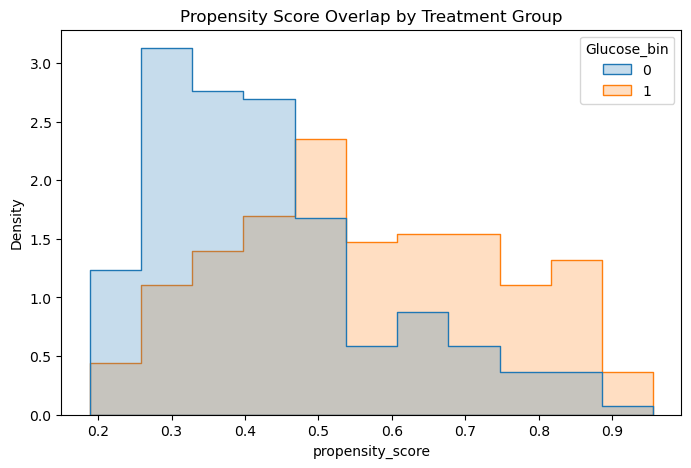


Running refutation tests...

Placebo Treatment Refuter Result:  Refute: Use a Placebo Treatment
Estimated effect:0.2796170659306685
New effect:-0.1779008507610101
p value:0.0

Random Common Cause Refuter Result:  Refute: Add a random common cause
Estimated effect:0.2796170659306685
New effect:0.2796170659306685
p value:1.0

Data Subset Refuter Result:  Refute: Use a subset of data
Estimated effect:0.2796170659306685
New effect:0.27792932914154056
p value:1.0

=== Dataset and causal inference summary sent to LLM ===

Dataset summary for causal inference:

Treatment variable: Glucose_bin (binary indicator if glucose > median)
  mean=0.50, std=0.50, min=0.00, max=1.00

Outcome variable: Outcome (binary diabetes diagnosis)
  Outcome distribution: {0: 262, 1: 130}

Confounders:
  Age: mean=0.00, std=1.00, min=-0.97, max=4.92
  BMI: mean=0.00, std=1.00, min=-2.12, max=4.85
  Pregnancies: mean=-0.00, std=1.00, min=-1.03, max=4.27


Estimated Average Treatment Effect (ATE) of Glucose_bin on O

OSError: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/mistralai/Mistral-7B-Instruct-v0.1.
403 Client Error. (Request ID: Root=1-682d609e-53ca394937da7a9269a64b0a;13cf5ce8-5559-4065-aab1-a0b4a9d8aae2)

Cannot access gated repo for url https://huggingface.co/mistralai/Mistral-7B-Instruct-v0.1/resolve/main/config.json.
Access to model mistralai/Mistral-7B-Instruct-v0.1 is restricted and you are not in the authorized list. Visit https://huggingface.co/mistralai/Mistral-7B-Instruct-v0.1 to ask for access.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from dowhy import CausalModel
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

# === Load and preprocess dataset ===
df = pd.read_csv("diabetes.csv")

# Check actual column names
expected_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
                 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
assert all(col in df.columns for col in expected_cols), f"Unexpected columns: {df.columns}"

# Replace invalid 0s with NaN and drop rows with missing values
cols_with_invalid_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_invalid_zeros] = df[cols_with_invalid_zeros].replace(0, np.nan)
df.dropna(inplace=True)

# Create binary treatment variable based on Glucose median
treatment = "Glucose_bin"
df[treatment] = (df["Glucose"] > df["Glucose"].median()).astype(int)
outcome = "Outcome"
confounders = ['Age', 'BMI', 'Pregnancies']

# Normalize confounders
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[confounders] = scaler.fit_transform(df[confounders])

# === DoWhy Causal Inference ===
model = CausalModel(
    data=df_scaled,
    treatment=treatment,
    outcome=outcome,
    common_causes=confounders
)

identified_estimand = model.identify_effect()

estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_weighting",
    target_units="ate"
)

print("Causal Estimate (ATE): ", estimate.value)

# === Propensity Score Analysis ===
ps_model = LogisticRegression(max_iter=1000)
ps_model.fit(df_scaled[confounders], df_scaled[treatment])
pscore = ps_model.predict_proba(df_scaled[confounders])[:, 1]
df_scaled['propensity_score'] = pscore

# Plotting
plt.figure(figsize=(8, 5))
sns.kdeplot(df_scaled.loc[df_scaled[treatment] == 1, 'propensity_score'], label='Treated')
sns.kdeplot(df_scaled.loc[df_scaled[treatment] == 0, 'propensity_score'], label='Control')
plt.title("Propensity Score Distribution by Treatment Group")
plt.xlabel("Propensity Score")
plt.ylabel("Density")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(data=df_scaled, x='propensity_score', hue=treatment, element="step", stat="density", common_norm=False)
plt.title("Propensity Score Overlap by Treatment Group")
plt.show()

# === Refutation Tests ===
print("\nRunning refutation tests...\n")
refute_placebo = model.refute_estimate(identified_estimand, estimate, method_name="placebo_treatment_refuter")
print("Placebo Treatment Refuter Result: ", refute_placebo)

refute_random_common_cause = model.refute_estimate(identified_estimand, estimate, method_name="random_common_cause")
print("Random Common Cause Refuter Result: ", refute_random_common_cause)

refute_subset = model.refute_estimate(identified_estimand, estimate, method_name="data_subset_refuter")
print("Data Subset Refuter Result: ", refute_subset)

# === Summarize for LLM ===
def summarize_feature(series):
    return f"mean={series.mean():.2f}, std={series.std():.2f}, min={series.min():.2f}, max={series.max():.2f}"

summary_text = f"""
Dataset summary for causal inference:

Treatment variable: {treatment} (binary indicator if glucose > median)
  {summarize_feature(df_scaled[treatment])}

Outcome variable: {outcome} (binary diabetes diagnosis)
  Outcome distribution: {df_scaled[outcome].value_counts().to_dict()}

Confounders:
"""
for c in confounders:
    summary_text += f"  {c}: {summarize_feature(df_scaled[c])}\n"

summary_text += f"""

Estimated Average Treatment Effect (ATE) of {treatment} on {outcome}: {estimate.value:.4f}

Diagnostics:
- Propensity score distribution plotted.
- Common support assumption checked.
- Refutation tests performed:
  * Placebo treatment refuter: {refute_placebo.new_effect}
  * Random common cause refuter: {refute_random_common_cause.new_effect}
  * Data subset refuter: {refute_subset.new_effect}

Please provide a detailed interpretation of this causal effect estimate,
discuss assumptions, potential sources of bias, robustness, and how
propensity score model diagnostics and sensitivity analyses inform confidence
in this estimate.
"""

print("=== Dataset and causal inference summary sent to LLM ===")
print(summary_text)

# === Load Mistral-7B (optimized for memory) ===
# model_name = "mistralai/Mistral-7B-Instruct-v0.1"
# tokenizer = AutoTokenizer.from_pretrained(model_name)

model_name = "mistralai/Mistral-7B-Instruct-v0.1"
token = "xxxxxxx"

tokenizer = AutoTokenizer.from_pretrained(model_name, token=token)
# model = AutoModelForCausalLM.from_pretrained(model_name, token=token)


llm_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    token=token,
    device_map="auto",
    torch_dtype=torch.float16  # GPU friendly
)

# === Generate LLM Response ===
def generate_interpretation(prompt, max_new_tokens=350):
    inputs = tokenizer(prompt, return_tensors="pt").to(llm_model.device)
    outputs = llm_model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        eos_token_id=tokenizer.eos_token_id,
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

causal_effect_interpretation = generate_interpretation(summary_text)

print("\n=== LLM Causal Effect Interpretation ===\n")
print(causal_effect_interpretation)


Causal Estimate (ATE):  0.2796170659306685


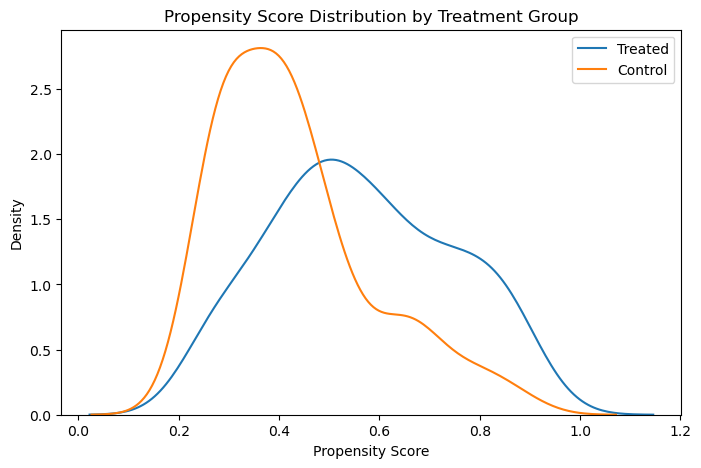

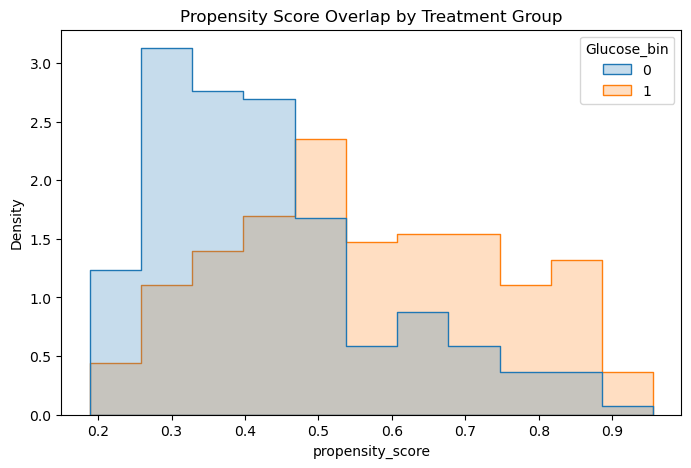


Running refutation tests...

Placebo Treatment Refuter Result:  Refute: Use a Placebo Treatment
Estimated effect:0.2796170659306685
New effect:-0.1759013609282364
p value:0.0

Random Common Cause Refuter Result:  Refute: Add a random common cause
Estimated effect:0.2796170659306685
New effect:0.2796170659306685
p value:1.0

Data Subset Refuter Result:  Refute: Use a subset of data
Estimated effect:0.2796170659306685
New effect:0.2804784378857031
p value:0.96

=== Dataset and causal inference summary sent to LLM ===

Dataset summary for causal inference:

Treatment variable: Glucose_bin (binary indicator if glucose > median)
  mean=0.50, std=0.50, min=0.00, max=1.00

Outcome variable: Outcome (binary diabetes diagnosis)
  Outcome distribution: {0: 262, 1: 130}

Confounders:
  Age: mean=0.00, std=1.00, min=-0.97, max=4.92
  BMI: mean=0.00, std=1.00, min=-2.12, max=4.85
  Pregnancies: mean=-0.00, std=1.00, min=-1.03, max=4.27


Estimated Average Treatment Effect (ATE) of Glucose_bin on O

/rodata/kern/m254629/miniconda3/envs/llama2/lib/python3.10/site-packages/transformers/models/auto/tokenization_auto.py:823: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(


OSError: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/mistralai/Mistral-7B-Instruct-v0.1.
403 Client Error. (Request ID: Root=1-682d61c8-24321f6c21aab6d770bb48a3;4b3617e2-9a67-4f69-ad0a-80bfc66f6bef)

Cannot access gated repo for url https://huggingface.co/mistralai/Mistral-7B-Instruct-v0.1/resolve/main/config.json.
Access to model mistralai/Mistral-7B-Instruct-v0.1 is restricted and you are not in the authorized list. Visit https://huggingface.co/mistralai/Mistral-7B-Instruct-v0.1 to ask for access.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from dowhy import CausalModel
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

# === Load and preprocess dataset ===
df = pd.read_csv("diabetes.csv")

# Check expected columns
expected_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
                 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
assert all(col in df.columns for col in expected_cols), f"Unexpected columns: {df.columns}"

# Replace invalid 0s with NaN and drop rows with missing values
cols_with_invalid_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_invalid_zeros] = df[cols_with_invalid_zeros].replace(0, np.nan)
df.dropna(inplace=True)

# Create binary treatment variable
treatment = "Glucose_bin"
df[treatment] = (df["Glucose"] > df["Glucose"].median()).astype(int)
outcome = "Outcome"
confounders = ['Age', 'BMI', 'Pregnancies']

# Normalize confounders
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[confounders] = scaler.fit_transform(df[confounders])

# === DoWhy Causal Inference ===
model = CausalModel(
    data=df_scaled,
    treatment=treatment,
    outcome=outcome,
    common_causes=confounders
)

identified_estimand = model.identify_effect()

estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_weighting",
    target_units="ate"
)

print("Causal Estimate (ATE): ", estimate.value)

# === Propensity Score Analysis ===
ps_model = LogisticRegression(max_iter=1000)
ps_model.fit(df_scaled[confounders], df_scaled[treatment])
pscore = ps_model.predict_proba(df_scaled[confounders])[:, 1]
df_scaled['propensity_score'] = pscore

# Plotting
plt.figure(figsize=(8, 5))
sns.kdeplot(df_scaled.loc[df_scaled[treatment] == 1, 'propensity_score'], label='Treated')
sns.kdeplot(df_scaled.loc[df_scaled[treatment] == 0, 'propensity_score'], label='Control')
plt.title("Propensity Score Distribution by Treatment Group")
plt.xlabel("Propensity Score")
plt.ylabel("Density")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(data=df_scaled, x='propensity_score', hue=treatment, element="step", stat="density", common_norm=False)
plt.title("Propensity Score Overlap by Treatment Group")
plt.show()

# === Refutation Tests ===
print("\nRunning refutation tests...\n")
refute_placebo = model.refute_estimate(identified_estimand, estimate, method_name="placebo_treatment_refuter")
print("Placebo Treatment Refuter Result: ", refute_placebo)

refute_random_common_cause = model.refute_estimate(identified_estimand, estimate, method_name="random_common_cause")
print("Random Common Cause Refuter Result: ", refute_random_common_cause)

refute_subset = model.refute_estimate(identified_estimand, estimate, method_name="data_subset_refuter")
print("Data Subset Refuter Result: ", refute_subset)

# === Summarize for LLM ===
def summarize_feature(series):
    return f"mean={series.mean():.2f}, std={series.std():.2f}, min={series.min():.2f}, max={series.max():.2f}"

summary_text = f"""
Dataset summary for causal inference:

Treatment variable: {treatment} (binary indicator if glucose > median)
  {summarize_feature(df_scaled[treatment])}

Outcome variable: {outcome} (binary diabetes diagnosis)
  Outcome distribution: {df_scaled[outcome].value_counts().to_dict()}

Confounders:
"""
for c in confounders:
    summary_text += f"  {c}: {summarize_feature(df_scaled[c])}\n"

summary_text += f"""

Estimated Average Treatment Effect (ATE) of {treatment} on {outcome}: {estimate.value:.4f}

Diagnostics:
- Propensity score distribution plotted.
- Common support assumption checked.
- Refutation tests performed:
  * Placebo treatment refuter: {refute_placebo.new_effect}
  * Random common cause refuter: {refute_random_common_cause.new_effect}
  * Data subset refuter: {refute_subset.new_effect}

Please provide a detailed interpretation of this causal effect estimate,
discuss assumptions, potential sources of bias, robustness, and how
propensity score model diagnostics and sensitivity analyses inform confidence
in this estimate.
"""

print("=== Dataset and causal inference summary sent to LLM ===")
print(summary_text)

# === Load Mistral-7B with Hugging Face token ===
model_name = "mistralai/Mistral-7B-Instruct-v0.1"
access_token = "xxxxx"

tokenizer = AutoTokenizer.from_pretrained(model_name, use_auth_token=access_token)
llm_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    torch_dtype=torch.float16,
    use_auth_token=access_token
)

# === Generate LLM Response ===
def generate_interpretation(prompt, max_new_tokens=350):
    inputs = tokenizer(prompt, return_tensors="pt").to(llm_model.device)
    outputs = llm_model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        eos_token_id=tokenizer.eos_token_id,
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

causal_effect_interpretation = generate_interpretation(summary_text)

print("\n=== LLM Causal Effect Interpretation ===\n")
print(causal_effect_interpretation)


In [1]:
# from trl import PPOConfig
# help(PPOConfig)

In [4]:
import trl
print(trl.__version__)

0.15.0
